In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
#charger le dataset Ag News
df_ag_news = pd.read_csv('../data/raw/AG-News.csv')

In [ ]:
df_ag_news.head()

,Class Index,Title,Description
0,3,Fears for T N pension after talks,Unions representing workers at Turner Newall...
1,4,The Race is On: Second Private Team Sets Launc...,"SPACE.com - TORONTO, Canada -- A second\team o..."
2,4,Ky. Company Wins Grant to Study Peptides (AP),AP - A company founded by a chemistry research...
3,4,Prediction Unit Helps Forecast Wildfires (AP),AP - It's barely dawn when Mike Fitzpatrick st...
4,4,Calif. Aims to Limit Farm-Related Smog (AP),AP - Southern California's smog-fighting agenc...


In [6]:
print(f"les valuers manquantes : {df_ag_news.isnull().sum()}")
print(f"les classes uniques:{df_ag_news['Class Index'].unique()}")

les valuers manquantes : Class Index    0
Title          0
Description    0
dtype: int64
les classes uniques:[3 4 2 1]


In [8]:

# A. On mappe les chiffres vers les vrais noms de catégories
class_mapping = {1: 'World', 2: 'Sports', 3: 'Business', 4: 'Sci/Tech'}
df_ag_news['category'] = df_ag_news['Class Index'].map(class_mapping)

# B. L'ASTUCE : On fusionne Titre et Description
# On convertit en string (str) pour éviter les erreurs si une case est vide
df_ag_news['text'] = df_ag_news['Title'].astype(str) + " " + df_ag_news['Description'].astype(str)

# C. On ne garde que les deux colonnes utiles, comme pour BBC News !
df_ag = df_ag_news[['category', 'text']]



In [9]:
print("\nAperçu du nouveau dataset :")
display(df_ag_news.head())


Aperçu du nouveau dataset :


,Class Index,Title,Description,category,text
0,3,Fears for T N pension after talks,Unions representing workers at Turner Newall...,Business,Fears for T N pension after talks Unions repre...
1,4,The Race is On: Second Private Team Sets Launc...,"SPACE.com - TORONTO, Canada -- A second\team o...",Sci/Tech,The Race is On: Second Private Team Sets Launc...
2,4,Ky. Company Wins Grant to Study Peptides (AP),AP - A company founded by a chemistry research...,Sci/Tech,Ky. Company Wins Grant to Study Peptides (AP) ...
3,4,Prediction Unit Helps Forecast Wildfires (AP),AP - It's barely dawn when Mike Fitzpatrick st...,Sci/Tech,Prediction Unit Helps Forecast Wildfires (AP) ...
4,4,Calif. Aims to Limit Farm-Related Smog (AP),AP - Southern California's smog-fighting agenc...,Sci/Tech,Calif. Aims to Limit Farm-Related Smog (AP) AP...



4. Affichage de la distribution...


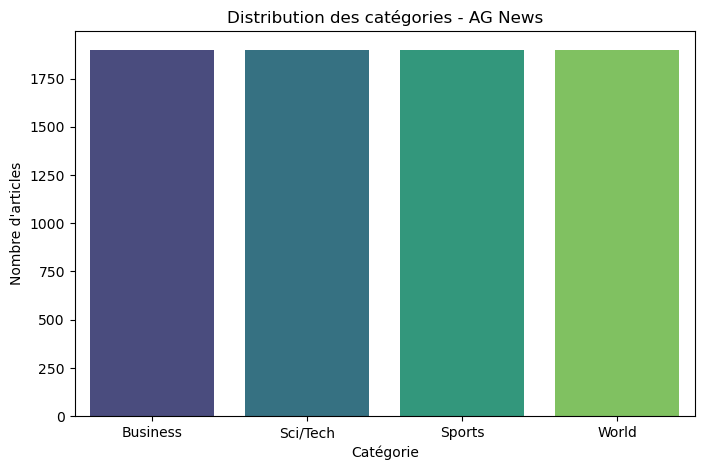

In [10]:


print("\n4. Affichage de la distribution...")
plt.figure(figsize=(8, 5))
sns.countplot(data=df_ag_news, x='category', palette='viridis', order=df_ag_news['category'].value_counts().index)
plt.title('Distribution des catégories - AG News')
plt.xlabel('Catégorie')
plt.ylabel("Nombre d'articles")
plt.show()

In [11]:
# sauvegarder le dataframe nettoyé
df_ag_news.to_csv('../data/processed/AG-News-cleaned.csv', index=False)